In [22]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.compose import ColumnTransformer

In [23]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
from form_suppliers_df import form_suppliers_df, filter_suppliers
from preprocessor import preprocess_tender_data

In [25]:
#data = pd.read_excel('/Users/polina/b2b_reccomendation_systems/data_final(2020-2025)/data_final_res(2020-2025)_revenue_with_null.xlsx')

In [26]:
#data = preprocess_tender_data(data)

In [27]:
data = pd.read_csv('/Users/polina/b2b_reccomendation_systems/preprocessed_full.csv')

In [28]:
data['Дата публикации'] = pd.to_datetime(data['Дата публикации'], format='mixed')

In [29]:
supplier_historical_data = form_suppliers_df(data)

Создано 112087 профилей с историческими данными поставщиков.


In [32]:
data[data['Реестровый номер публикации'] == 31907572182]

,Unnamed: 0,Уровень,Заказчик,ИНН заказчика,Стоимость(руб.) Заказчик,Реестровый номер публикации,Сфера деятельности,Регион поставки,Город поставки,Дата публикации,...,avg_competitors_in_sphere,avg_competitors_in_customer,is_january,days_between,publication_peak_9_11,app_end_noon_12,app_start_night_12,trade_end_night_12,is_2019,is_jan_to_april
136203,136219,2,"ФГАОУ ВО РУТ (МИИТ), РУТ (МИИТ)",7715027733,120000.0,31907572182,"[ОКПД2 33.12] Услуги по ремонту оборудования, ...",Москва,Москва,2019-02-25 19:53:20,...,2.89657,3.42471,0,7,0,0,1,0,1,1
136204,136220,2,"ФГАОУ ВО РУТ (МИИТ), РУТ (МИИТ)",7715027733,120000.0,31907572182,"[ОКПД2 33.12] Услуги по ремонту оборудования, ...",Москва,Москва,2019-02-25 19:53:20,...,2.89657,3.42471,0,7,0,0,1,0,1,1
136205,136221,2,"ФГАОУ ВО РУТ (МИИТ), РУТ (МИИТ)",7715027733,120000.0,31907572182,"[ОКПД2 33.12] Услуги по ремонту оборудования, ...",Москва,Москва,2019-02-25 19:53:20,...,2.89657,3.42471,0,7,0,0,1,0,1,1


Найдем тендеры для тестирования

In [33]:
from form_suppliers_df import select_test_tenders

train_data = data[data['year'].isin(range(2015, 2021))]
test_data = data[data['year'].isin(range(2021, 2026))]
valid_test = select_test_tenders(data)

112087 уникальных поставщиков в данных

Найдено 109820 валидных тендеров.

Тендер 1/5:
ID: 31907617472
Количество участников: 2
Информация об участниках:
- Участник -
ИНН: 5506200081
Участий в данных: 60
Побед в данных:   16
----------------------------------------
* ПОБЕДИТЕЛЬ *
ИНН: 5503103234
Участий в данных: 49
Побед в данных:   29
----------------------------------------

Тендер 2/5:
ID: 31907703218
Количество участников: 2
Информация об участниках:
- Участник -
ИНН: 2721216761
Участий в данных: 72
Побед в данных:   19
----------------------------------------
* ПОБЕДИТЕЛЬ *
ИНН: 281602248952
Участий в данных: 12
Побед в данных:   7
----------------------------------------

Тендер 3/5:
ID: 31907659716
Количество участников: 3
Информация об участниках:
- Участник -
ИНН: 6674238890
Участий в данных: 16
Побед в данных:   5
----------------------------------------
* ПОБЕДИТЕЛЬ *
ИНН: 6659190900
Участий в данных: 8
Побед в данных:   5
----------------------------------------
- Участник

In [35]:
from form_suppliers_df import format_tender_info_dict

In [36]:
tender_subset_df = data[data['Реестровый номер публикации'] == 31907617472]
new_tender_info = format_tender_info_dict(tender_subset_df)

In [37]:
new_tender_info

{'Регион поставки': 'Ханты-Мансийский автономный округ - Югра (Тюменская область)',
 'Город поставки': 'Ханты-Мансийский автономный округ - Югра (Тюменская область)',
 'Сфера деятельности': '[ОКПД2 10.5+] Молоко и молочная продукция, [ОКВЭД2 10.5+] Производство молочной продукции',
 'Заказчик': 'МАОУ "КСОШ-ДС"',
 'ИНН заказчика': np.int64(8612009244),
 'Стоимость(руб.) Заказчик': np.float64(645956.9),
 'Дата публикации': '2019-03-07 13:21:54',
 'Дата окончания приема заявок / Дата планового окончания исполнения контракта / Плановая дата публикации лота по ППГ': '2019-03-18 12:00:00',
 'Дата начала подачи заявок / Дата начала исполнения контракта / Дата публикации ППГ': '2019-03-07',
 'Дата окончания проведения торгов': '2019-03-18 18:00:00',
 'Форма публикации': 'Торговая процедура',
 'Снижение на торгах,%': 0,
 'Тип торгов': 'Неизвестно',
 'Статус допуска': 0,
 'is_january': np.int64(0),
 'days_between': np.int64(11),
 'publication_peak_9_11': np.int64(0),
 'app_end_noon_12': np.int64

In [ ]:
new_tender_df = pd.DataFrame([new_tender_info])
use_filtered = True 

if use_filtered:
    if 'regions_set' in supplier_historical_data.columns and 'spheres_set' in supplier_historical_data.columns:
        active_supplier_pool = filter_suppliers(supplier_historical_data, new_tender_df)
    else:
        print("Столбцы 'regions_set' или 'spheres_set' отсутствуют. Используются все поставщики.")
        active_supplier_pool = supplier_historical_data.copy() 
else:
    active_supplier_pool = supplier_historical_data.copy() 

num_suppliers_to_predict = active_supplier_pool.shape[0]

Получено 10 поставщиков по региону 'Ханты-Мансийский автономный округ - Югра (Тюменская область)' и сфере '[ОКПД2 10.5+] Молоко и молочная продукция, [ОКВЭД2 10.5+] Производство молочной продукции'


In [41]:
if num_suppliers_to_predict > 0:
    tender_df_repeated = pd.concat([new_tender_df] * num_suppliers_to_predict, ignore_index=True)
    suppliers_reset = active_supplier_pool.reset_index(drop=True)
    prediction_input_df = pd.concat([suppliers_reset, tender_df_repeated], axis=1)

    num_features = [
    "avg_price_drop",
    "log_cost",
    "log_profit",
    "Снижение на торгах,%",
    'win_rate',  'region_win_rate', 
    'customer_win_rate', 'sphere_win_rate',
    "days_between",
    "region_wins",
    "customer_wins",
    "sphere_wins",
    "total_wins",
    "competitors_per_tender",
    "avg_competitors_in_region",
    "avg_competitors_in_sphere",
    "avg_competitors_in_customer",
    "Обеспечение заявки (руб.)",
    "Обеспечение заявки, %",
    "Обеспечение контракта (руб.)",
    "Обеспечение контракта, %"
    ]

    cat_features = [
    "Сфера деятельности",
    "Регион поставки",
    "Город поставки",
    "Тип торгов",
    "Уровень",
    "year",
    "month",
    "Сводный риск"
    ]

    binary_features = [
    "РНП ранее", 
    "is_january", 
    "publication_peak_9_11", 
    "app_end_noon_12", 
    "app_start_night_12",
    "trade_end_night_12",
    "is_2019",
    "Статус допуска",
    "is_jan_to_april"
    ]

    all_features_needed = num_features + cat_features + binary_features
    final_columns = ['ИНН поставщика'] + all_features_needed
    missing_cols = [col for col in final_columns if col not in prediction_input_df.columns]
    if missing_cols:
        print(f"Следующие столбцы отсутствуют в prediction_input_df: {missing_cols}")
    else:
        prediction_input_final = prediction_input_df[final_columns].copy() 
        # Сохраняем ИНН поставщиков отдельно для сопоставления результатов
        supplier_inns_predict = prediction_input_final['ИНН поставщика']
        prediction_data_for_model = prediction_input_final.drop(columns=['ИНН поставщика'])

In [42]:
prediction_data_for_model

,avg_price_drop,log_cost,log_profit,"Снижение на торгах,%",win_rate,region_win_rate,customer_win_rate,sphere_win_rate,days_between,region_wins,...,Сводный риск,РНП ранее,is_january,publication_peak_9_11,app_end_noon_12,app_start_night_12,trade_end_night_12,is_2019,Статус допуска,is_jan_to_april
0,0.230592,13.37849,19.527423,0,0.0,0.591837,0.591837,0.591837,11,6.0,...,1,0,0,0,1,1,0,1,0,1
1,0.190544,13.37849,19.095673,0,0.0,0.213483,0.213483,0.213483,11,1.0,...,3,0,0,0,1,1,0,1,0,1
2,0.213685,13.37849,20.461662,0,0.0,0.266667,0.266667,0.266667,11,2.0,...,1,0,0,0,1,1,0,1,0,1
3,0.196087,13.37849,22.562070,0,0.0,0.432990,0.432990,0.432990,11,19.0,...,1,0,0,0,1,1,0,1,0,1
4,0.222118,13.37849,19.272727,0,0.0,0.452555,0.452555,0.452555,11,62.0,...,1,0,0,0,1,1,0,1,0,1
5,0.197984,13.37849,18.837593,0,0.0,0.041667,0.041667,0.041667,11,1.0,...,1,0,0,0,1,1,0,1,0,1
6,0.236524,13.37849,21.475491,0,0.0,0.142857,0.142857,0.142857,11,1.0,...,0,0,0,0,1,1,0,1,0,1
7,0.132911,13.37849,21.325044,0,0.0,0.250000,0.250000,0.250000,11,0.0,...,0,0,0,0,1,1,0,1,0,1
8,0.251887,13.37849,21.397412,0,0.0,0.187500,0.187500,0.187500,11,3.0,...,0,0,0,0,1,1,0,1,0,1
9,0.160717,13.37849,20.914590,0,0.0,0.233645,0.233645,0.233645,11,25.0,...,0,0,0,0,1,1,0,1,0,1


Теперь можем протестировать модельки


In [43]:
import joblib

In [44]:
loaded_knn_pipeline = joblib.load('models_joblib/best_knn_pipeline_model.joblib')
predictions_knn = loaded_knn_pipeline.predict_proba(prediction_data_for_model)[:, 1]

In [45]:
loaded_svc_pipeline = joblib.load('models_joblib/linear_svc_model.joblib')
predictions_svc = loaded_svc_pipeline.predict(prediction_data_for_model)

In [46]:
from tqdm.auto import tqdm 
from torch.utils.data import DataLoader 
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

/Users/polina/b2b_reccomendation_systems/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [47]:
class TenderNet(nn.Module):
    def __init__(self, input_size: int, hidden_size1: int = 512, hidden_size2: int = 32, dropout_rate: float = 0.4):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, hidden_size1),
            nn.Tanh(),
            nn.BatchNorm1d(hidden_size1),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_size1, hidden_size2),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_size2),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_size2, 1)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layers(x)

In [48]:
def predict_proba(
    model: nn.Module,
    X: pd.DataFrame,
    preprocessor: ColumnTransformer,
    device: torch.device,
    batch_size: int = 256
) -> np.ndarray:
    X_proc = preprocessor.transform(X)
    data = torch.tensor(X_proc, dtype=torch.float32)
    loader = DataLoader(data, batch_size=batch_size, shuffle=False)
    model.eval()
    probs = []
    with torch.no_grad():
        for xb in loader:
            xb = xb.to(device)
            logits = model(xb)
            probs.append(torch.sigmoid(logits).cpu().numpy())
    return np.vstack(probs).squeeze()

In [49]:
checkpoint = torch.load('models_joblib/tender_mlp_model_and_preprocessor.pth', map_location=device, weights_only=False)
loaded_preprocessor = checkpoint['preprocessor']
loaded_input_size = checkpoint['input_size']
loaded_state = checkpoint['model_state_dict']
loaded_model = TenderNet(input_size=loaded_input_size).to(device)
loaded_model.load_state_dict(loaded_state)
loaded_model.eval()
predictions_mlp = predict_proba(loaded_model, prediction_data_for_model, loaded_preprocessor, device)

In [50]:
pd.options.display.float_format = '{:,.2f}'.format 

results_df = pd.DataFrame({
                'ИНН поставщика': supplier_inns_predict,
                'SVM_prediction': predictions_svc,
                'KNN_prediction': predictions_knn,
                'MLP_prediction': predictions_mlp
            })

            
results_df_sorted_svm = results_df.sort_values(by='SVM_prediction', ascending=False)
print("\nРезультаты предсказаний (Топ 5 по SVM):")
print(results_df_sorted_svm.head(10))


Результаты предсказаний (Топ 5 по SVM):
   ИНН поставщика  SVM_prediction  KNN_prediction  MLP_prediction
0      5503103234               1            0.48            1.00
1      5503135155               0            0.07            1.00
2      5506200081               0            0.04            1.00
3      7203239260               0            0.34            1.00
4      8603109002               0            0.42            1.00
5      8603218315               0            0.01            0.00
6    450100096884               0            0.05            0.03
7    667007558708               0            0.01            0.65
8    860301109019               0            0.05            0.04
9    860301328003               0            0.16            1.00


In [51]:
results_df_sorted_knn = results_df.sort_values(by='KNN_prediction', ascending=False)
print("\nРезультаты предсказаний (Топ 5 по KNN):")
print(results_df_sorted_knn.head(10))


Результаты предсказаний (Топ 5 по KNN):
   ИНН поставщика  SVM_prediction  KNN_prediction  MLP_prediction
0      5503103234               1            0.48            1.00
4      8603109002               0            0.42            1.00
3      7203239260               0            0.34            1.00
9    860301328003               0            0.16            1.00
1      5503135155               0            0.07            1.00
6    450100096884               0            0.05            0.03
8    860301109019               0            0.05            0.04
2      5506200081               0            0.04            1.00
7    667007558708               0            0.01            0.65
5      8603218315               0            0.01            0.00


In [52]:
results_df_sorted_mlp = results_df.sort_values(by='MLP_prediction', ascending=False)
print("\nРезультаты предсказаний (Топ 10 по MLP):")
print(results_df_sorted_mlp.head(10))


Результаты предсказаний (Топ 10 по MLP):
   ИНН поставщика  SVM_prediction  KNN_prediction  MLP_prediction
0      5503103234               1            0.48            1.00
3      7203239260               0            0.34            1.00
4      8603109002               0            0.42            1.00
9    860301328003               0            0.16            1.00
1      5503135155               0            0.07            1.00
2      5506200081               0            0.04            1.00
7    667007558708               0            0.01            0.65
8    860301109019               0            0.05            0.04
6    450100096884               0            0.05            0.03
5      8603218315               0            0.01            0.00


In [54]:
tender_subset_df[(tender_subset_df['Реестровый номер публикации'] == 31907617472) & (tender_subset_df['Победитель'] == 1)]['ИНН поставщика']

168649    5503103234
Name: ИНН поставщика, dtype: int64

Проверим среднее попадание по части валидных тендеров

In [55]:
def recall_at_k(predicted_inns, actual_winners, k):
    if not actual_winners:
        return 0.0 

    predicted_top_k = set(predicted_inns[:k])
    relevant_items_count = len(actual_winners.intersection(predicted_top_k))
    return float(relevant_items_count) / float(len(actual_winners))

def precision_at_k(predicted_inns, actual_winners, k):
    if k == 0:
        return 0.0

    predicted_top_k = set(predicted_inns[:k])
    relevant_items_count = len(actual_winners.intersection(predicted_top_k))
    return float(relevant_items_count) / float(k)

def dcg_at_k(predicted_inns, actual_winners, k):
    dcg = 0.0
    for i, inn in enumerate(predicted_inns[:k]):
        if inn in actual_winners:
            # Relevance is 1 for winners, 0 otherwise
            # Rank is i+1, denominator is log2(rank + 1) = log2(i + 2)
            dcg += 1.0 / np.log2(float(i) + 2.0)
    return dcg

def ndcg_at_k(predicted_inns, actual_winners, k):
    actual_dcg = dcg_at_k(predicted_inns, actual_winners, k)
    ideal_ranking = sorted(list(actual_winners), key=lambda x: 1, reverse=True) 
    ideal_dcg = dcg_at_k(ideal_ranking, actual_winners, k)
    if ideal_dcg == 0:
        return 0.0

    return actual_dcg / ideal_dcg

In [57]:
import random

all_known_suppliers= set(data['ИНН поставщика'].unique())

def get_supplier_stats(inn):
    supplier_records = data[data['ИНН поставщика'] == inn]
    wins = 0
    if 'Победитель' in supplier_records.columns:
        wins = int(supplier_records['Победитель'].sum())
    return {
            'records_count': len(supplier_records),
            'wins_count': wins
    }

valid_tenders = []
all_tender_ids = data['Реестровый номер публикации'].unique()

processed_count = 0
for tender_id in all_tender_ids:
    tender_data = data[data['Реестровый номер публикации'] == tender_id]
    participants = tender_data['ИНН поставщика'].unique()
    num_participants = len(participants)
    if all(inn in all_known_suppliers for inn in participants) and num_participants >= 1:
        winner_data = tender_data[tender_data['Победитель'] == 1]
        if not winner_data.empty:
            winner_inn = winner_data['ИНН поставщика'].iloc[0]
            valid_tenders.append({
                        'tender_id': tender_id,
                        'participants_count': num_participants,
                        'winner_inn': winner_inn
                    })
    processed_count += 1

print(f"\nНайдено {len(valid_tenders)} валидных тендеров")
selected_tenders_data = []
selected_sample = random.sample(valid_tenders, 25)


Найдено 224055 валидных тендеров


In [69]:
from contextlib import redirect_stdout
import random

k_values = [1, 3, 5, 10, 20]
num_samples_to_process = 1000
output_filename = 'check_results_with_metrics.txt'
use_filtered = True

metrics_results = [] 
processed_tender_count = 0
skipped_tender_count = 0

num_samples_to_process = min(num_samples_to_process, len(valid_tenders))
selected_sample = random.sample(valid_tenders, num_samples_to_process)

print(f"Starting evaluation for {len(selected_sample)} tenders...")
print(f"Metrics will be calculated for K = {k_values}")

for tender_info_dict in selected_sample: 
    print(tender_info_dict)
    tender_id = tender_info_dict['tender_id']
    winner_inn_val = tender_info_dict['winner_inn'] 

    if np.isnan(winner_inn_val):
        skipped_tender_count += 1
        continue

    winner_inn_int = int(winner_inn_val)
    actual_winners_set = {winner_inn_int} 
 
    tender_subset_df = data[data['Реестровый номер публикации'] == tender_id]
    if tender_subset_df.empty:
        skipped_tender_count += 1
        continue

    actual_winner_check = tender_subset_df[tender_subset_df['Победитель'] == 1]['ИНН поставщика'].tolist()
    if not actual_winner_check or winner_inn_int not in actual_winner_check:
        skipped_tender_count += 1
        continue

    new_tender_info_pred = format_tender_info_dict(tender_subset_df)
    new_tender_df_pred = pd.DataFrame([new_tender_info_pred])
    
    if use_filtered:
        active_supplier_pool = filter_suppliers(supplier_historical_data, new_tender_df_pred)
    else:
        active_supplier_pool = supplier_historical_data.copy()

    num_suppliers_to_predict = active_supplier_pool.shape[0]

    if num_suppliers_to_predict == 0:
        print(f"Skipping tender {tender_id}: No suppliers in the filtered pool.") 
        skipped_tender_count += 1
        continue

    tender_df_repeated = pd.concat([new_tender_df_pred] * num_suppliers_to_predict, ignore_index=True)
    active_supplier_pool = active_supplier_pool.loc[~active_supplier_pool.index.duplicated(keep='first')]
    suppliers_reset = active_supplier_pool.reset_index(drop=True) 
    prediction_input_df = pd.concat([suppliers_reset, tender_df_repeated], axis=1)

    all_features_needed = num_features + cat_features + binary_features
    final_columns = ['ИНН поставщика'] + all_features_needed
    missing_cols = [col for col in final_columns if col not in prediction_input_df.columns]

    prediction_input_final = prediction_input_df[final_columns].copy()
    supplier_inns_predict = prediction_input_final['ИНН поставщика']
    prediction_data_for_model = prediction_input_final.drop(columns=['ИНН поставщика'])


    predicted_inns_pool_set = set(supplier_inns_predict.tolist())
    if not actual_winners_set.intersection(predicted_inns_pool_set):
        print(f"Skipping tender {tender_id}: Winner {actual_winners_set} not in the prediction pool.") 
        skipped_tender_count += 1
        continue 

    predictions_knn = loaded_knn_pipeline.predict_proba(prediction_data_for_model)[:, 1]
    predictions_svm = loaded_svc_pipeline.predict(prediction_data_for_model)
    predictions_mlp = predict_proba(loaded_model, prediction_data_for_model, loaded_preprocessor, device)

    results_df = pd.DataFrame({
            'ИНН поставщика': supplier_inns_predict, 
            'SVM_prediction': predictions_svm,
            'KNN_prediction': predictions_knn,
            'MLP_prediction': predictions_mlp
    })


    for model_name in ['SVM', 'KNN', 'MLP']:
        col_name = f'{model_name}_prediction'
        sorted_df = results_df.sort_values(by=col_name, ascending=False, na_position='last')
        predicted_inns_list = sorted_df['ИНН поставщика'].tolist()

        for k in k_values:
            effective_k = min(k, num_suppliers_to_predict)
            if effective_k > 0: 
                recall = recall_at_k(predicted_inns_list, actual_winners_set, effective_k)
                precision = precision_at_k(predicted_inns_list, actual_winners_set, effective_k)
                ndcg = ndcg_at_k(predicted_inns_list, actual_winners_set, effective_k)

                metrics_results.append({
                        'tender_id': tender_id,
                        'model': model_name,
                        'k': k, 
                        'recall': recall,
                        'precision': precision,
                        'ndcg': ndcg,
                        'num_predicted': num_suppliers_to_predict,
                        'num_winners': len(actual_winners_set)
                })
    processed_tender_count += 1 


print(f"Successfully processed tenders: {processed_tender_count}")
print(f"Skipped tenders (due to errors, missing data, or winner not in pool): {skipped_tender_count}")
print(f"Collected {len(metrics_results)} metric results points.")

metrics_df = pd.DataFrame(metrics_results)

Starting evaluation for 1000 tenders...
Metrics will be calculated for K = [1, 3, 5, 10, 20]
{'tender_id': np.int64(31907544688), 'participants_count': 3, 'winner_inn': np.int64(1901109904)}
Получено 4 поставщиков по региону 'Республика Хакасия' и сфере '[ОКПД2 49.20] Услуги железнодорожного транспорта по перевозке грузов, [ОКВЭД2 49.20] Деятельность железнодорожного транспорта: грузовые перевозки'
{'tender_id': np.int64(32211185332), 'participants_count': 1, 'winner_inn': np.int64(3826000289)}
Получено 2 поставщиков по региону 'Иркутская область' и сфере '[ОКПД2 01.47] Птица сельскохозяйственная живая и яйца, [ОКВЭД2 56.29] Деятельность предприятий общественного питания по прочим видам организации питания'
{'tender_id': np.int64(32211184791), 'participants_count': 4, 'winner_inn': np.int64(6670460220)}
Получено 75 поставщиков по региону 'Санкт-Петербург' и сфере '[ОКПД2 58.19] Услуги в области издательской деятельности прочие, [ОКВЭД2 58.19] Виды издательской деятельности прочие'
{'te

In [70]:
metrics_df.head(15)

,tender_id,model,k,recall,precision,ndcg,num_predicted,num_winners
0,31907544688,SVM,1,1.00,1.00,1.00,4,1
1,31907544688,SVM,3,1.00,0.33,1.00,4,1
2,31907544688,SVM,5,1.00,0.25,1.00,4,1
3,31907544688,SVM,10,1.00,0.25,1.00,4,1
4,31907544688,SVM,20,1.00,0.25,1.00,4,1
5,31907544688,KNN,1,1.00,1.00,1.00,4,1
6,31907544688,KNN,3,1.00,0.33,1.00,4,1
7,31907544688,KNN,5,1.00,0.25,1.00,4,1
8,31907544688,KNN,10,1.00,0.25,1.00,4,1
9,31907544688,KNN,20,1.00,0.25,1.00,4,1


In [71]:
agg_metrics = metrics_df.groupby(['model', 'k'])[['recall', 'precision', 'ndcg']].mean().reset_index()
print("\nAggregated Metrics (Mean):")
print(agg_metrics)
 
agg_metrics_median = metrics_df.groupby(['model', 'k'])[['recall', 'precision', 'ndcg']].median().reset_index()
print("\nAggregated Metrics (Median):")
print(agg_metrics_median)


Aggregated Metrics (Mean):
   model   k  recall  precision  ndcg
0    KNN   1    0.21       0.21  0.21
1    KNN   3    0.36       0.16  0.30
2    KNN   5    0.45       0.15  0.34
3    KNN  10    0.57       0.14  0.37
4    KNN  20    0.70       0.13  0.41
5    MLP   1    0.15       0.15  0.15
6    MLP   3    0.29       0.14  0.23
7    MLP   5    0.36       0.13  0.26
8    MLP  10    0.46       0.13  0.29
9    MLP  20    0.58       0.12  0.32
10   SVM   1    0.16       0.16  0.16
11   SVM   3    0.33       0.15  0.26
12   SVM   5    0.41       0.14  0.29
13   SVM  10    0.51       0.13  0.32
14   SVM  20    0.64       0.13  0.35

Aggregated Metrics (Median):
   model   k  recall  precision  ndcg
0    KNN   1    0.00       0.00  0.00
1    KNN   3    0.00       0.00  0.00
2    KNN   5    0.00       0.00  0.00
3    KNN  10    1.00       0.10  0.33
4    KNN  20    1.00       0.05  0.33
5    MLP   1    0.00       0.00  0.00
6    MLP   3    0.00       0.00  0.00
7    MLP   5    0.00       0.0

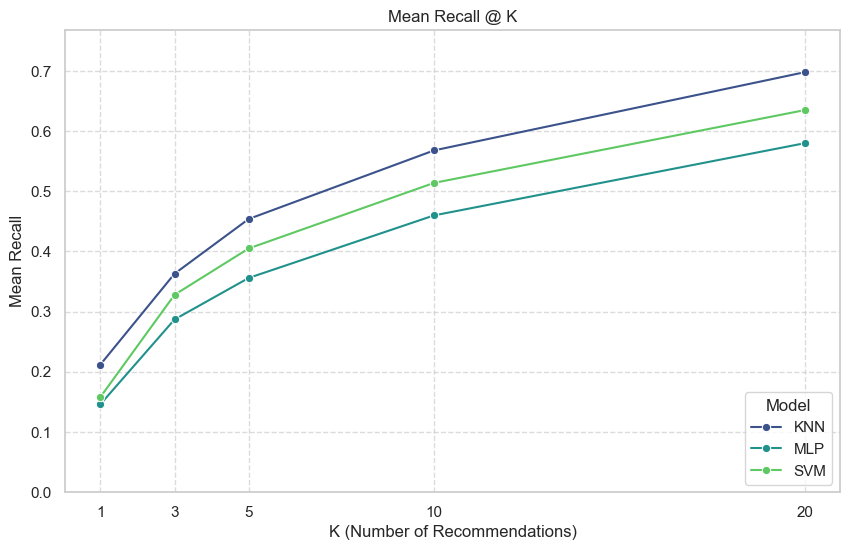

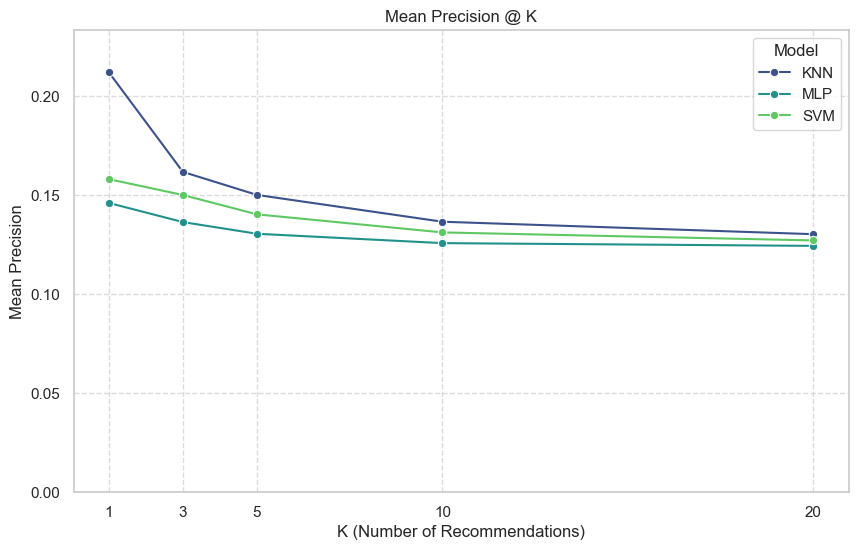

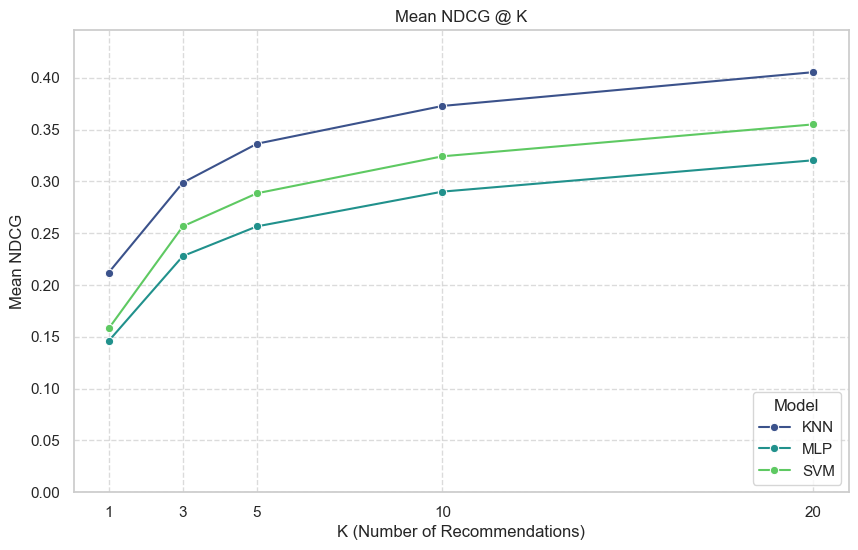

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

#Recall@K
plt.figure(figsize=(10, 6))
sns.lineplot(data=agg_metrics, x='k', y='recall', hue='model', marker='o', palette='viridis')
plt.title('Mean Recall @ K')
plt.xlabel('K (Number of Recommendations)')
plt.ylabel('Mean Recall')
plt.xticks(k_values) 
plt.legend(title='Model', loc='lower right')
plt.ylim(0, max(agg_metrics['recall'].max() * 1.1, 0.1)) 
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#Precision@K
plt.figure(figsize=(10, 6))
sns.lineplot(data=agg_metrics, x='k', y='precision', hue='model', marker='o', palette='viridis')
plt.title('Mean Precision @ K')
plt.xlabel('K (Number of Recommendations)')
plt.ylabel('Mean Precision')
plt.xticks(k_values)
plt.legend(title='Model', loc='upper right')
plt.ylim(0, max(agg_metrics['precision'].max() * 1.1, 0.1)) 
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# NDCG@K
plt.figure(figsize=(10, 6))
sns.lineplot(data=agg_metrics, x='k', y='ndcg', hue='model', marker='o', palette='viridis')
plt.title('Mean NDCG @ K')
plt.xlabel('K (Number of Recommendations)')
plt.ylabel('Mean NDCG')
plt.xticks(k_values)
plt.legend(title='Model', loc='lower right')
plt.ylim(0, max(agg_metrics['ndcg'].max() * 1.1, 0.1)) 
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


In [74]:
from contextlib import redirect_stdout

winner_ranks_list = []
output_filename = 'check_results.txt'

with open(output_filename, 'w', encoding='utf-8') as f:
    with redirect_stdout(f):
        for i in selected_sample:
            if not np.isnan(i['winner_inn']):
                tender = i['tender_id']
                tender_subset_df = data[data['Реестровый номер публикации'] == tender]
                winner_series = tender_subset_df[tender_subset_df['Победитель'] == 1]['ИНН поставщика']
                print(f"Реальный победитель: {winner_series}")
                new_tender_info = format_tender_info_dict(tender_subset_df)
                new_tender_df = pd.DataFrame([new_tender_info])

                use_filtered = True 
                active_supplier_pool = filter_suppliers(supplier_historical_data, new_tender_df)
                num_suppliers_to_predict = active_supplier_pool.shape[0]

                if num_suppliers_to_predict > 0:
                    tender_df_repeated = pd.concat([new_tender_df] * num_suppliers_to_predict, ignore_index=True)
                    suppliers_reset = active_supplier_pool.reset_index(drop=True)
                    prediction_input_df = pd.concat([suppliers_reset, tender_df_repeated], axis=1)
                    all_features_needed = num_features + cat_features + binary_features
                    final_columns = ['ИНН поставщика'] + all_features_needed
                    prediction_input_final = prediction_input_df[final_columns].copy()
                    supplier_inns_predict = prediction_input_final['ИНН поставщика']
                    prediction_data_for_model = prediction_input_final.drop(columns=['ИНН поставщика'])

                    predictions_knn = loaded_knn_pipeline.predict_proba(prediction_data_for_model)[:, 1]
                    predictions_svm = loaded_svc_pipeline.predict(prediction_data_for_model)
                    predictions_mlp = predict_proba(loaded_model, prediction_data_for_model, loaded_preprocessor, device)
                    
                    results_df = pd.DataFrame({
                    'ИНН поставщика': supplier_inns_predict,
                    'SVM_prediction': predictions_svm,
                    'KNN_prediction': predictions_knn,
                    'MLP_prediction': predictions_mlp
                    })

                    ranks = {
                    'tender_id': tender,
                    'real_winners_inns': winner_series,
                    'num_participants_predicted': num_suppliers_to_predict
                    }

                    if len(winner_series) > 0: 
                        predicted_inns_set = set(results_df['ИНН поставщика'].values)
                        winners_found_in_predictions = [inn for inn in winner_series if inn in predicted_inns_set]

                        if not winners_found_in_predictions:
                            print(f"  Предупреждение: Ни один из реальных победителей {winner_series} не найден в списке предсказанных поставщиков ({num_suppliers_to_predict} шт.).")
                            continue
                        else:
                            if len(winners_found_in_predictions) < len(winner_series):
                                print(f"  Предупреждение: Не все реальные победители найдены в предсказаниях. Найдены: {winners_found_in_predictions}")

                            for model_name in ['SVM', 'KNN', 'MLP']:
                                col_name = f'{model_name}_prediction'
                                sorted_df = results_df.sort_values(by=col_name, ascending=False).reset_index(drop=True)
                                found_ranks_for_model = []
                                for winner_inn in winners_found_in_predictions:
                                    winner_position = sorted_df[sorted_df['ИНН поставщика'] == winner_inn].index
                                    if not winner_position.empty:
                                        rank = winner_position[0] + 1 
                                        found_ranks_for_model.append(rank)

                                if found_ranks_for_model:
                                    avg_rank = np.mean(found_ranks_for_model)
                                    ranks[f'{model_name}_rank'] = avg_rank
                                    print(f"  Ранги найденных победителей ({model_name}): {found_ranks_for_model} -> Средний ранг: {avg_rank:.2f} из {num_suppliers_to_predict}")
                                    winner_ranks_list.append(ranks)
                                    print("-" * 70) 
                    else:
                        continue
                else: 
                    continue
            else:
                continue

In [75]:
winner_ranks_df = pd.DataFrame(winner_ranks_list)

In [76]:
winner_ranks_df[['SVM_rank', 'KNN_rank', 'MLP_rank']].agg(['mean', 'median', 'std'])

,SVM_rank,KNN_rank,MLP_rank
mean,42.81,33.11,46.49
median,10.00,7.00,13.00
std,96.47,73.97,93.15


In [27]:
#результаты старых моделей, оставлены для сравнения (на SVM не смотрим, он теперь бинарный классификатор без вероятностей)
winner_ranks_df[['SVM_rank', 'KNN_rank', 'MLP_rank']].agg(['mean', 'median', 'std'])

,SVM_rank,KNN_rank,MLP_rank
mean,12.959233,11.635492,13.736211
median,3.000000,3.000000,3.000000
std,31.101866,24.978737,28.667369


In [77]:
#код для того, чтобы посмотреть на конкретные тендеры

tenders_to_check = [32211357812]

for tender in tenders_to_check:
    tender_subset_df = data[data['Реестровый номер публикации'] == tender]
    new_tender_info = format_tender_info_dict(tender_subset_df)
    new_tender_df = pd.DataFrame([new_tender_info])
    use_filtered = True 
    if 'regions_set' in supplier_historical_data.columns and 'spheres_set' in supplier_historical_data.columns:
        active_supplier_pool = filter_suppliers(supplier_historical_data, new_tender_df)

    num_suppliers_to_predict = active_supplier_pool.shape[0]
    if num_suppliers_to_predict > 0:
        tender_df_repeated = pd.concat([new_tender_df] * num_suppliers_to_predict, ignore_index=True)
        suppliers_reset = active_supplier_pool.reset_index(drop=True)
        prediction_input_df = pd.concat([suppliers_reset, tender_df_repeated], axis=1)
        all_features_needed = num_features + cat_features + binary_features
        final_columns = ['ИНН поставщика'] + all_features_needed
        prediction_input_final = prediction_input_df[final_columns].copy() 
        supplier_inns_predict = prediction_input_final['ИНН поставщика']
        prediction_data_for_model = prediction_input_final.drop(columns=['ИНН поставщика'])

        predictions_knn = loaded_knn_pipeline.predict_proba(prediction_data_for_model)[:, 1]
        predictions_svm = loaded_svc_pipeline.predict(prediction_data_for_model)
        predictions_mlp = predict_proba(loaded_model, prediction_data_for_model, loaded_preprocessor, device)
        results_df = pd.DataFrame({
                'ИНН поставщика': supplier_inns_predict,
                'SVM_prediction': predictions_svm,
                'KNN_prediction': predictions_knn,
                'MLP_prediction': predictions_mlp
            })

        print(f"Реальный победитель тендера: {tender_subset_df[(tender_subset_df['Реестровый номер публикации'] == tender) & (tender_subset_df['Победитель'] == 1)]['ИНН поставщика']}\n")

        results_df_sorted_svm = results_df.sort_values(by='SVM_prediction', ascending=False)
        print("\nРезультаты предсказаний (Топ 10 по SVM):")
        print(results_df_sorted_svm.head(10))
        results_df_sorted_knn = results_df.sort_values(by='KNN_prediction', ascending=False)
        print("\nРезультаты предсказаний (Топ 10 по KNN):")
        print(results_df_sorted_knn.head(10))
        results_df_sorted_mlp = results_df.sort_values(by='MLP_prediction', ascending=False)
        print("\nРезультаты предсказаний (Топ 10 по MLP):")
        print(results_df_sorted_mlp.head(10))

Получено 312 поставщиков по региону 'Краснодарский край' и сфере '[ОКПД2 71.12] Услуги в области инженерно-технического проектирования и связанные технические консультативные услуги, [ОКВЭД2 71.12] Деятельность в области инженерных изысканий, инженерно-технического проектирования, управления проектами строительства, выполнения строительного контроля и авторского надзора, предоставление технических консультаций в этих областях'
Реальный победитель тендера: 472302    2308131521
Name: ИНН поставщика, dtype: int64


Результаты предсказаний (Топ 10 по SVM):
     ИНН поставщика  SVM_prediction  KNN_prediction  MLP_prediction
96       2315184098               1            0.54            1.00
100      2315988451               1            0.57            1.00
255      7727015468               1            0.08            1.00
97       2315185366               1            0.55            1.00
192      6345030007               1            0.33            1.00
256      7727061249              

Теперь добавим часть по дополнению предикта моделей: будем брать профиль победителя, и на основе фильтров отбирать максимально похожие компании

In [78]:
rev = pd.read_excel('/Users/polina/b2b_reccomendation_systems/revenue_spark_final.xlsx')

In [79]:
rev.head()

,ИНН поставщика,Адрес,Отрасль,Выручка,Персонал,Сводный риск
0,272909593,"450095, Башкортостан Респ, г.о. город Уфа, г У...","Торговля оптовая лесоматериалами, строительным...",NaN,1.00,Высокий риск
1,7805363761,"198095, г. Санкт-Петербург, ул. Зои Космодемья...",Строительство водных сооружений,"59,590,000.00",14.00,Низкий риск
2,2320033513,"354000, Краснодарский кр., г. Сочи, проспект К...",Деятельность гостиниц и прочих мест для времен...,"340,240,000.00",104.00,Низкий риск
3,7722327689,"630007, Новосибирская обл., г. Новосибирск, ул...",Деятельность курьерская,"42,435,330,000.00",NaN,Низкий риск
4,6453128666,"410065, Саратовская обл., г. Саратов, ул. Одес...",Торговля оптовая одеждой и обувью,NaN,NaN,Недействующий


In [80]:
rev.shape

(79912, 6)

In [81]:
rev.isna().sum()

ИНН поставщика        0
Адрес              1100
Отрасль            1081
Выручка           23621
Персонал          23050
Сводный риск        121
dtype: int64

Пропуски в адресе и отрасли можем дропнуть - это маленькая часть данных, а для предложения похожих компаний профиль должен быть полным. Пропуски в сводном риске (да и в целом сводный риск) обработаем аналогично основному подходу. Пропуски в выручке и персонале можем заполнить через Iterative Imputer - он показал наилучшие результаты в предыдущих экспериментах

In [82]:
rev = rev.dropna(subset=['Адрес', 'Отрасль'])

In [83]:
rev.loc[rev['Сводный риск'] == 'Высокий риск', 'Сводный риск'] = 3
rev.loc[rev['Сводный риск'] == 'Средний риск', 'Сводный риск'] = 2
rev.loc[rev['Сводный риск'] == 'Низкий риск', 'Сводный риск'] = 1
rev.loc[(rev['Сводный риск'] == 'Риск не определен') | (rev['Сводный риск'] == 'Недействующий'), 'Сводный риск'] = 0

print(rev['Сводный риск'].describe())
print(rev['Сводный риск'].value_counts())
print(f"Количество пропусков в сводном риске: {rev['Сводный риск'].isna().sum()}")

count     78808
unique        4
top           1
freq      44243
Name: Сводный риск, dtype: int64
Сводный риск
1    44243
0    12664
2    12379
3     9522
Name: count, dtype: int64
Количество пропусков в сводном риске: 0


In [84]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor


imputer = IterativeImputer(estimator=RandomForestRegressor(n_estimators=100, random_state=42, bootstrap=True), max_iter=10, verbose=2)
rev[['Персонал', 'Выручка']] = imputer.fit_transform(rev[['Персонал', 'Выручка']])

[IterativeImputer] Completing matrix with shape (78808, 2)
[IterativeImputer] Ending imputation round 1/10, elapsed time 8.76
[IterativeImputer] Change: 54982765949.8625, scaled tolerance: 3791566978.0 
[IterativeImputer] Ending imputation round 2/10, elapsed time 17.46
[IterativeImputer] Change: 796653122.5, scaled tolerance: 3791566978.0 
[IterativeImputer] Early stopping criterion reached.


In [85]:
rev.isna().sum()

ИНН поставщика    0
Адрес             0
Отрасль           0
Выручка           0
Персонал          0
Сводный риск      0
dtype: int64

Теперь разберемся с географическими признаками: в основных данных у нас есть регион и город, здесь у нас кроме этого также имеется и адрес. Обработаем, для того, чтобы в дальнейшем считать расстояние между предсказынным победителем и похожими компаниями

In [86]:
rev['Адрес'].iloc[0]

'450095, Башкортостан Респ, г.о. город Уфа, г Уфа, ул Центральная, д. 23, офис 306'

In [87]:
rev['Адрес'].iloc[4]

'410065, Саратовская обл., г. Саратов, ул. Одесская, д. 19'

In [88]:
rev['Адрес'].iloc[7]

'413100, Саратовская обл., г. Энгельс, ул. Степная, д. 61 пом. 5'

In [89]:
pd.set_option('display.max_columns', None)

address_components = rev['Адрес'].str.split(',', expand=True).apply(lambda x: x.str.strip())
address_components.columns = [f'comp_{i}' for i in range(address_components.shape[1])]
address_components

,comp_0,comp_1,comp_2,comp_3,comp_4,comp_5,comp_6,comp_7,comp_8,comp_9,comp_10,comp_11,comp_12,comp_13,comp_14,comp_15,comp_16,comp_17,comp_18,comp_19,comp_20,comp_21,comp_22,comp_23,comp_24,comp_25,comp_26
0,450095,Башкортостан Респ,г.о. город Уфа,г Уфа,ул Центральная,д. 23,офис 306,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
1,198095,г. Санкт-Петербург,ул. Зои Космодемьянской,д. 20 литера А,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
2,354000,Краснодарский кр.,г. Сочи,проспект Курортный,д. 50,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
3,630007,Новосибирская обл.,г. Новосибирск,ул. Кривощековская,д. 15 к. 1 этаж 1,2,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
4,410065,Саратовская обл.,г. Саратов,ул. Одесская,д. 19,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79907,660028,Красноярский край,г.о. город Красноярск,г Красноярск,ул Телевизорная,д. 1,стр. 9,помещ. 126,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
79908,353387,Краснодарский кр.,Крымский район,г. Крымск,ул. Темченко,д. 16Б,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
79909,107589,г. Москва,ул. Красноярская,д. 11 к. А,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None
79910,681024,Хабаровский край,г.о. город Комсомольск-на-Амуре,г Комсомольск-на-Амуре,пр-кт Интернациональный,д. 47,кв. 76,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None


In [90]:
import pandas as pd

num_cols_to_analyze = 6

print("Уникальные значения в столбцах:")
for i in range(num_cols_to_analyze):
    col_name = address_components.columns[i] 
    unique_values = address_components[col_name].dropna().unique()
    if len(unique_values) < 9000: 
        print(f"\n--- Столбец {col_name} ---")
        print(sorted(list(unique_values)))
    else:
         print(f"\n--- Столбец {col_name} ---")
         print(f"(Пропущено, >200 уникальных значений: {len(unique_values)})")


Уникальные значения в столбцах:

--- Столбец comp_0 ---
['050500', '101000', '101001', '101990', '103006', '103012', '103030', '103045', '103064', '103070', '103132', '105005', '105037', '105043', '105062', '105064', '105066', '105077', '105082', '105094', '105118', '105120', '105122', '105173', '105187', '105203', '105215', '105264', '105275', '105318', '105425', '105484', '105505', '105523', '105554', '105568', '105613', '107014', '107023', '107031', '107045', '107061', '107065', '107066', '107076', '107078', '107113', '107140', '107143', '107150', '107174', '107199', '107207', '107241', '107258', '107370', '107392', '107497', '107553', '107564', '107589', '107996', '108801', '108802', '108803', '108805', '108807', '108808', '108809', '108810', '108811', '108813', '108814', '108817', '108818', '108819', '108820', '108821', '108823', '108824', '108825', '108826', '108827', '108828', '108829', '108830', '108831', '108832', '108833', '108834', '108836', '108840', '108841', '108842', '10

In [91]:
address_components.dropna()

,comp_0,comp_1,comp_2,comp_3,comp_4,comp_5,comp_6,comp_7,comp_8,comp_9,comp_10,comp_11,comp_12,comp_13,comp_14,comp_15,comp_16,comp_17,comp_18,comp_19,comp_20,comp_21,comp_22,comp_23,comp_24,comp_25,comp_26
28956,344011,Ростовская обл,г.о. город Ростов-на-Дону,г Ростов-на-Дону,пр-кт Буденновский,зд. 97,этаж 2,3,ком. 1А,1Б,1В,1Г,1Д,1Е,1Ж,2,3,3А,3Б,4,4А,4Б,1-5-6-7,2,3,4,4А


In [94]:
data['Регион поставки'].value_counts().head(15)

Регион поставки
Москва                              84496
Санкт-Петербург                     24998
Московская область                  24300
Свердловская область                20196
Республика Башкортостан             17212
Краснодарский край                  13544
Нижегородская область               11954
Челябинская область                 11784
Иркутская область                   11563
Красноярский край                   10787
Саратовская область                 10359
Новосибирская область                9882
Тюменская область                    9662
Самарская область                    9454
Республика Татарстан (Татарстан)     9306
Name: count, dtype: int64

In [103]:
import re

def clean_geocomponent(text):
    if text is None:
        return None

    text = re.sub(r'\s*\([^)]*\)$', '', text) 
    text = text.replace('обл.', 'обл').replace('область', 'обл')
    text = text.replace('кр.', 'край')
    text = text.replace('респ.', 'респ').replace('Респ', 'респ').replace('республика', 'респ').replace('Республика', 'респ')
    text = text.replace('а.о.', 'ао').replace('автономный округ', 'ао').replace('Автономный округ', 'ао')
    text = text.replace('г.', 'г').replace('Город', 'г')
    text = text.replace('авт.', 'автономная обл').replace('Аобл', 'автономная обл')
    text = text.replace('Кемеровская обл- Кузбасс', 'Кемеровская - Кузбасс обл')


    text = ' '.join(text.split())

    region_types = {
        'обл': 'обл',
        'край': 'край',
        'респ': 'респ',
        'ао': 'ао',
        # 'округ': 'округ' 
    }
    special_cases = ['г Москва', 'г Санкт-Петербург', 'г Севастополь', 'г Байконур']

    if text.lower() in [sc.lower() for sc in special_cases]:
        if text.lower() == 'г москва': return 'г Москва'
        if text.lower() == 'г санкт-петербург': return 'г Санкт-Петербург'
        if text.lower() == 'г севастополь': return 'г Севастополь'
        if text.lower() == 'г байконур': return 'г Байконур'
        return text 

    found_type = None
    name_parts = []
    words = text.split()

    for word in words:
        word_lower = word.lower()
        if word_lower in region_types:
            found_type = region_types[word_lower]
        else:
            name_parts.append(word)

    region_name = ' '.join(name_parts)

    if found_type:
        return f"{region_name} {found_type}"
    else:
        return text

print(clean_geocomponent('респ Хакасия'))
print(clean_geocomponent('Хакасия Респ'))
print(clean_geocomponent('Московская область'))
print(clean_geocomponent('Московская обл.'))
print(clean_geocomponent('Краснодарский кр.'))
print(clean_geocomponent('Ханты-Мансийский Автономный округ - Югра'))
print(clean_geocomponent('г. Москва'))
print(clean_geocomponent('Город Санкт-Петербург'))
print(clean_geocomponent('Республика Татарстан(Татарстан)'))

Хакасия респ
Хакасия респ
Московская обл
Московская обл
Краснодарский край
Ханты-Мансийский - Югра ао
г Москва
г Санкт-Петербург
Татарстан респ


In [104]:
def clean_city_name(city_text):
    if city_text is None:
        return None

    city_text = re.sub(r'\s*\([^)]*\)$', '', city_text)

    # "г.о. город/г Название" -> "г Название"
    match = re.match(r'г\.?о\.?\s+(?:г\.?|город)\s+(.*)', city_text, re.IGNORECASE)
    if match:
        city_name_part = match.group(1)
        city_text = 'г ' + city_name_part
    else:
        city_text = re.sub(r'^(город|г\.)\s+', 'г ', city_text, flags=re.IGNORECASE)
        city_text = re.sub(r'^(пос\.|поселок)\s+', 'пос ', city_text, flags=re.IGNORECASE)
        city_text = re.sub(r'^(село|с\.)\s+', 'с ', city_text, flags=re.IGNORECASE)
        city_text = re.sub(r'^(деревня|дер\.|д\.)\s+', 'дер ', city_text, flags=re.IGNORECASE) # Заменяем д. на дер. для ясности
        city_text = re.sub(r'^(станица|ст-ца|ст\.)\s+', 'ст ', city_text, flags=re.IGNORECASE)
        city_text = re.sub(r'^(р\.п\.|рабочий поселок)\s+', 'рп ', city_text, flags=re.IGNORECASE)
        city_text = re.sub(r'^(пгт|пгт\.|п\.г\.т\.)\s+', 'пгт ', city_text, flags=re.IGNORECASE)
 
    return ' '.join(city_text.split())

In [105]:
def extract_region(components):
    region_keywords = [
        'область', 'обл', 'обл.',
        'край', 'кр.',
        'республика','респ', 'респ.',
        'автономный округ', 'округ', 'ао', 'а.о.',
    ]

    special_regions_patterns = {
        r'\b(г\.|город)\s+москва\b': 'г. Москва',
        r'\b(г\.|город)\s+санкт-петербург\b': 'г. Санкт-Петербург',
        r'\b(г\.|город)\s+севастополь\b': 'г. Севастополь',
        r'\bсевастополь\b': 'г. Севастополь',
        r'\b(г\.|город)\s+байконур\b': 'г. Байконур', 
        r'\bбайконур\b': 'г. Байконур'
    }
    address_part_keywords = ['ул', 'просп', 'пер', 'д.', 'дом', 'литер', 'лит', 'пом', 'кв', 'стр', 'корп', 'этаж', 'офис', 'участок']

    special_region_found = None
    for comp in components:
        if comp is None: continue
        comp_lower = comp.strip().lower()
        for pattern, standardized_name in special_regions_patterns.items():
            if re.search(pattern, comp_lower, re.IGNORECASE):
                special_region_found = standardized_name
                break
        if special_region_found:
            break
    if special_region_found:
        return clean_geocomponent(special_region_found)

    for comp in components:
        if comp is None:
            continue

        comp_strip = comp.strip()
        comp_lower = comp_strip.lower()
        if comp_lower.startswith('вн.тер.г.'):
            continue

        for keyword in region_keywords:
            if re.search(r'\b' + re.escape(keyword) + r'\b', comp_lower) or comp_lower.endswith(keyword):
                if keyword in ['ао', 'а.о.', 'округ']:
                    if any(re.search(r'\b' + re.escape(addr_kw) + r'\b', comp_lower) for addr_kw in address_part_keywords):
                        continue
                    if re.search(r'\d', comp_strip):
                        continue

                cleaned_comp = re.sub(r'\([^)]*\)$', '', comp_strip).strip()
                return clean_geocomponent(cleaned_comp)

    return None

In [106]:
def extract_city(components, region_component=None):
    settlement_prefixes = [
        'г.', 'г ', 'город ', 'г.о. г', 'г.о. город', # города
        'пгт.', 'пгт ', 'п.г.т.',                       # пгт
        'р.п.', 'рп ', 'рабочий поселок ',            # рп
        'к.п.', 'кп ', 'курортный поселок ',          # кп
        'пос.', 'пос ', 'п.', 'п ', 'поселок ',        # поселки
        'с.', 'с ', 'село ',                          # села
        'ст-ца', 'ст.', 'станица ',                   # станицы
        'дер.', 'д.', 'д ', 'деревня ',               # деревни
        'х.', 'х ', 'хутор ',                         # хутора
        'аул '                                         # аулы
    ]
    settlement_patterns = [re.compile(r'^\s*' + re.escape(p), re.IGNORECASE) for p in settlement_prefixes]
    address_check_prefixes = ['д.', 'д ', 'дер.', 'деревня ', 'с.', 'с ', 'село ']
    district_keywords = ['район', 'р-н', 'м.р.', 'с.п.', 'сельсовет', 'г.о.', 'улус', 'округ', 'с/с', 'м/о', 'с/а', 'с/о', 'с/п']

    address_part_keywords = [
        'улица', 'ул', 'просп', 'пр-кт', 'пр-т', 'пер', 'переулок', 'бульвар', 'б-р', 'б-р.',
        'аллея', 'шоссе', 'ш.', 'наб', 'набережная', 'площадь', 'пл', 'проезд', 'тракт', 'км', 'километр',
        'квартал', 'кв-л', 'линия',
        'дом', 'двлд', 'влд', 'владение', 
        'литера', 'лит.', 'пом.', 'помещение', 'кв.', 'квартира', 'стр.', 'строение', 'сооружение', 'соор.',
        'корп.', 'корпус', 'к.', 'этаж', 'эт.', 'офис', 'оф.', 'участок', 'уч.', 'зд.', 'здание',
        'гараж', 'бокс', 'кабинет', 'каб.', 'комната', 'ком.', 'комн', 'ж/д_рзд',
        'номер', '№'
    ]

    
    federal_cities = ['г Москва', 'г Санкт-Петербург', 'г Севастополь', 'г Байконур']
    cleaned_region = clean_geocomponent(region_component) if region_component else None
    if cleaned_region and cleaned_region in federal_cities:
        return region_component

    region_index = -1
    if cleaned_region and components:
        for i, comp in enumerate(components):
            if comp and clean_geocomponent(comp) == cleaned_region:
                region_index = i
                break

    potential_city_prefixed = None
    potential_city_no_prefix = None
    found_after_region = (region_index == -1)
    for i, comp in enumerate(components):
        if comp is None: continue
        comp_strip = comp.strip()
        if not comp_strip: continue
        comp_lower = comp_strip.lower()

        if i == region_index:
            found_after_region = True
            continue 

        if comp_lower.startswith('вн.тер.г.'): continue

        is_prefixed_settlement = False
        matched_prefix = None
        for j, pattern in enumerate(settlement_patterns):
            if pattern.match(comp_strip):
                current_prefix = settlement_prefixes[j]
                rest_of_comp = pattern.sub('', comp_strip).strip() 
                is_actually_address = False
                if current_prefix in address_check_prefixes:
                    if not rest_of_comp or \
                       re.search(r'^\d', rest_of_comp) or \
                       any(rest_of_comp.lower().startswith(kw) for kw in ['дом', 'литер', 'корп', 'стр', 'участ']):
                        is_actually_address = True
                    elif any(re.search(r'\b' + re.escape(kw) + r'\b', rest_of_comp, re.IGNORECASE) for kw in address_part_keywords):
                         is_actually_address = True

                if is_actually_address:
                    continue 

                is_just_district = False
                if not current_prefix.lower().startswith('г.о. г'):
                    comp_body = pattern.sub('', comp_strip).strip() 
                    if comp_body.lower() in district_keywords or \
                       any(re.fullmatch(re.escape(kw) + r'\b.*', comp_body, re.IGNORECASE) for kw in district_keywords if kw=='г.о.'): # г.о. Суксунский
                        is_just_district = True

                if is_just_district:
                    continue 
                # Нашли город/НП с префиксом!
                potential_city_prefixed = comp_strip
                is_prefixed_settlement = True
                break 

        if is_prefixed_settlement:
            break

        is_district = comp_lower in district_keywords or \
                      any(re.search(r'\b' + re.escape(kw) + r'\b', comp_lower) for kw in district_keywords)

        is_address_part = any(re.search(r'\b' + re.escape(kw) + r'\b', comp_lower) for kw in address_part_keywords) or \
                          re.search(r'\d+', comp_lower) # Если есть цифры, скорее всего адрес

        if is_district or is_address_part:
            continue 
        if found_after_region and potential_city_no_prefix is None:
            potential_city_no_prefix = comp_strip

    if potential_city_prefixed:
        return potential_city_prefixed
    elif potential_city_no_prefix:
        return potential_city_no_prefix
    else:
        return None
    

components_list = address_components.apply(lambda row: row.dropna().tolist(), axis=1)

rev['Регион'] = components_list.apply(extract_region)
rev['Город_raw'] = [extract_city(comps, rev.loc[idx, 'Регион']) for idx, comps in components_list.items()]
rev['Город'] = rev['Город_raw'].apply(clean_city_name)

In [107]:
print("\nСтатистика по городам (топ-20):")
print(rev['Город'].value_counts().head(20))


Статистика по городам (топ-20):
Город
г Москва             13743
г Санкт-Петербург     6741
г Екатеринбург        2824
г Новосибирск         1952
г Нижний Новгород     1590
г Уфа                 1493
г Казань              1335
г Красноярск          1177
г Краснодар           1017
г Тюмень               990
г Самара               970
г Челябинск            932
г Пермь                911
г Иркутск              879
г Воронеж              837
г Хабаровск            788
г Саратов              759
г Омск                 731
г Барнаул              666
г Ижевск               642
Name: count, dtype: int64


In [108]:
print("\nСтатистика по регионам:")
print(rev['Регион'].value_counts().head(20))


Статистика по регионам:
Регион
г Москва              13743
г Санкт-Петербург      6741
Свердловская обл       3655
Московская обл         3242
Краснодарский край     2414
Башкортостан респ      2287
Новосибирская обл      2176
Нижегородская обл      2076
Татарстан респ         1985
Челябинская обл        1927
Самарская обл          1880
Красноярский край      1728
Пермский край          1529
Ростовская обл         1528
Иркутская обл          1338
Тюменская обл          1180
Саратовская обл        1139
Приморский край        1124
Хабаровский край       1095
Волгоградская обл      1057
Name: count, dtype: int64


In [109]:
rev.isna().sum()

ИНН поставщика     0
Адрес              0
Отрасль            0
Выручка            0
Персонал           0
Сводный риск       0
Регион             0
Город_raw         41
Город             41
dtype: int64

Как будто, 41 пропуск в городе имеет право на существование, можем пойти дальше

In [110]:
rev['Регион'].unique()

array(['Башкортостан респ', 'г Санкт-Петербург', 'Краснодарский край',
       'Новосибирская обл', 'Саратовская обл', 'Свердловская обл',
       'Ярославская обл', 'Смоленская обл', 'г Москва', 'Кировская обл',
       'Татарстан респ', 'Амурская обл', 'Ульяновская обл',
       'Рязанская обл', 'Кемеровская - Кузбасс обл', 'Челябинская обл',
       'Курская обл', 'Иркутская обл', 'Тыва респ', 'Астраханская обл',
       'Оренбургская обл', 'Нижегородская обл', 'Пензенская обл',
       'Воронежская обл', 'Приморский край', 'Самарская обл',
       'Мурманская обл', 'Ленинградская обл', 'Калининградская обл',
       'Пермский край', 'Хабаровский край', 'Бурятия респ',
       'Ростовская обл', 'Коми респ', 'Красноярский край',
       'Сахалинская обл', 'Владимирская обл', 'Московская обл',
       'Ставропольский край', 'Белгородская обл', 'Ямало-Ненецкий ао',
       'Чувашская - Чувашия респ', 'Тюменская обл', 'Калужская обл',
       'Архангельская обл', 'Костромская обл', 'Камчатский край',

In [111]:
rev[rev['Город'].isna()]['Адрес']

1414     188506, Ленинградская обл., Ломоносовский райо...
3106     170546, Тверская обл., Калининский район, с/п ...
4223     423634, Татарстан респ., Елабужский район, км....
5122     188510, Ленинградская обл., Ломоносовский райо...
7590     632901, Новосибирская обл., Краснозерский райо...
7755     302209, Орловская обл., Орловский район, с/п П...
10654    305520, Курская обл., Курский район, д. 1-Я Мо...
12142    614524, Пермский кр., Пермский район, с. Усть-...
13133    630526, Новосибирская обл., Новосибирский райо...
14307    188507, Ленинградская обл., Ломоносовский райо...
18727    624016, Свердловская обл., Сысертский район, п...
21807    624005, Свердловская обл., Сысертский район, п...
22342    427000, Удмуртская респ., Завьяловский район, ...
24390    665466, Иркутская обл., Усольский район, ул. У...
25140    188510, Ленинградская обл., Ломоносовский райо...
27471    423887, Татарстан респ., Тукаевский район, тер...
27666    170546, Тверская обл., Калининский район, с/п .

Теперь построим фильтры по топ 5 предсказаний моделей 

In [114]:
tender_subset_df = data[data['Реестровый номер публикации'] == 31907617472]
new_tender_info = format_tender_info_dict(tender_subset_df)
new_tender_df = pd.DataFrame([new_tender_info])
use_filtered = True 

if use_filtered:
    if 'regions_set' in supplier_historical_data.columns and 'spheres_set' in supplier_historical_data.columns:
        active_supplier_pool = filter_suppliers(supplier_historical_data, new_tender_df)
    else:
        print("Столбцы 'regions_set' или 'spheres_set' отсутствуют. Используются все поставщики.")
        active_supplier_pool = supplier_historical_data.copy() 
else:
    active_supplier_pool = supplier_historical_data.copy() 

num_suppliers_to_predict = active_supplier_pool.shape[0]

if num_suppliers_to_predict > 0:
    tender_df_repeated = pd.concat([new_tender_df] * num_suppliers_to_predict, ignore_index=True)
    suppliers_reset = active_supplier_pool.reset_index(drop=True)
    prediction_input_df = pd.concat([suppliers_reset, tender_df_repeated], axis=1)

    num_features = [
    "avg_price_drop",
    "log_cost",
    "log_profit",
    "Снижение на торгах,%",
    'win_rate',  'region_win_rate', 
    'customer_win_rate', 'sphere_win_rate',
    "days_between",
    "region_wins",
    "customer_wins",
    "sphere_wins",
    "total_wins",
    "competitors_per_tender",
    "avg_competitors_in_region",
    "avg_competitors_in_sphere",
    "avg_competitors_in_customer",
    "Обеспечение заявки (руб.)",
    "Обеспечение заявки, %",
    "Обеспечение контракта (руб.)",
    "Обеспечение контракта, %"
    ]

    cat_features = [
    "Сфера деятельности",
    "Регион поставки",
    "Город поставки",
    "Тип торгов",
    "Уровень",
    "year",
    "month",
    "Сводный риск"
    ]

    binary_features = [
    "РНП ранее", 
    "is_january", 
    "publication_peak_9_11", 
    "app_end_noon_12", 
    "app_start_night_12",
    "trade_end_night_12",
    "is_2019",
    "Статус допуска",
    "is_jan_to_april"
    ]

    all_features_needed = num_features + cat_features + binary_features
    final_columns = ['ИНН поставщика'] + all_features_needed
    missing_cols = [col for col in final_columns if col not in prediction_input_df.columns]
    if missing_cols:
        print(f"Следующие столбцы отсутствуют в prediction_input_df: {missing_cols}")
    else:
        prediction_input_final = prediction_input_df[final_columns].copy() 
    
        supplier_inns_predict = prediction_input_final['ИНН поставщика']
        prediction_data_for_model = prediction_input_final.drop(columns=['ИНН поставщика'])

predictions_knn = loaded_knn_pipeline.predict_proba(prediction_data_for_model)[:, 1]
predictions_svc = loaded_svc_pipeline.predict(prediction_data_for_model)
predictions_mlp = predict_proba(loaded_model, prediction_data_for_model, loaded_preprocessor, device)

print(tender_subset_df[(tender_subset_df['Реестровый номер публикации'] == 31907617472) & (tender_subset_df['Победитель'] == 1)]['ИНН поставщика'])

results_df = pd.DataFrame({
                'ИНН поставщика': supplier_inns_predict,
                'SVM_prediction': predictions_svc,
                'KNN_prediction': predictions_knn,
                'MLP_prediction': predictions_mlp
            })

            
results_df_sorted_svm = results_df.sort_values(by='SVM_prediction', ascending=False)
print("\nРезультаты предсказаний (Топ 5 по SVM):")
print(results_df_sorted_svm.head())

results_df_sorted_knn = results_df.sort_values(by='KNN_prediction', ascending=False)
print("\nРезультаты предсказаний (Топ 5 по KNN):")
print(results_df_sorted_knn.head())

results_df_sorted_mlp = results_df.sort_values(by='MLP_prediction', ascending=False)
print("\nРезультаты предсказаний (Топ 10 по MLP):")
print(results_df_sorted_mlp.head())

Получено 10 поставщиков по региону 'Ханты-Мансийский автономный округ - Югра (Тюменская область)' и сфере '[ОКПД2 10.5+] Молоко и молочная продукция, [ОКВЭД2 10.5+] Производство молочной продукции'
168649    5503103234
Name: ИНН поставщика, dtype: int64

Результаты предсказаний (Топ 5 по SVM):
   ИНН поставщика  SVM_prediction  KNN_prediction  MLP_prediction
0      5503103234               1            0.48            1.00
1      5503135155               0            0.07            1.00
2      5506200081               0            0.04            1.00
3      7203239260               0            0.34            1.00
4      8603109002               0            0.42            1.00

Результаты предсказаний (Топ 5 по KNN):
   ИНН поставщика  SVM_prediction  KNN_prediction  MLP_prediction
0      5503103234               1            0.48            1.00
4      8603109002               0            0.42            1.00
3      7203239260               0            0.34            1.00
9   

In [128]:
import warnings
warnings.filterwarnings('ignore')

In [129]:
def recommend_companies(rev, forecast_inn, FOI = 0.65, FE = 0.25, FCEA= 1.0):
    """
    - Выручка и Персонал по порогам
    - Отраслевая совместимость
    - Географическое совпадение (сначала по городу, если нет — по региону)
    """
    forecast = rev.loc[rev['ИНН поставщика'] == forecast_inn].iloc[0]
    rev_forecast = forecast['Выручка']
    emp_forecast = forecast['Персонал']
    industry_forecast = forecast['Отрасль']
    region_forecast = forecast['Регион']
    city_forecast = forecast['Город']
    risk_forecast = forecast['Сводный риск']
    
    rev_min = FOI * rev_forecast
    emp_min = FE * emp_forecast
    
    base_filtered = rev[
        (rev['Выручка'] >= rev_min) &
        (rev['Персонал'] >= emp_min) &
        (rev['Отрасль'] == industry_forecast) &
        (rev['Сводный риск'] <= risk_forecast)
    ].copy()

    same_city = base_filtered[base_filtered['Город'] == city_forecast]
    
    if len(same_city) > 0:
        final_filtered = same_city
    else:
        final_filtered = base_filtered[base_filtered['Регион'] == region_forecast]
    
    final_filtered.loc[:, 'rev_min'] = rev_min
    final_filtered.loc[:, 'emp_min'] = emp_min
    
    return final_filtered

forecast_inn = results_df_sorted_mlp['ИНН поставщика'].iloc[0]
recommended = recommend_companies(rev, forecast_inn, FOI=0.65, FE=0.25)
recommended

,ИНН поставщика,Адрес,Отрасль,Выручка,Персонал,Сводный риск,Регион,Город_raw,Город,rev_min,emp_min
17121,5503103234,"644008, Омская обл., г. Омск, ул. Красный Путь...","Торговля оптовая молочными продуктами, яйцами ...","302,449,000.00",11.00,1,Омская обл,г. Омск,г Омск,"196,591,850.00",2.75
20006,5506200081,"644041, Омская обл., г. Омск, ул. Кирова, д. 4...","Торговля оптовая молочными продуктами, яйцами ...","769,816,000.00",36.00,1,Омская обл,г. Омск,г Омск,"196,591,850.00",2.75


In [170]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans

class SupplierRecommender:
    def __init__(self, rev, FOI = 0.65, FE = 0.25, FCEA = 1.0, tfidf_threshold= 0.7, n_clusters = 30):
        """
        FOI, FE: экономические фильтры
        tfidf_threshold: порог косинусной близости для отрасли
        n_clusters: количество кластеров для кластеризации отраслей
        """
        self.rev = rev.copy()
        if not self.rev.index.is_unique:
            self.rev = self.rev.reset_index(drop=True)

        self.FOI = FOI
        self.FE = FE
        self.FCEA = FCEA
        self.tfidf_threshold = tfidf_threshold
        self.n_clusters = n_clusters

        self.vectorizer = TfidfVectorizer()
        self.tfidf_matrix = self.vectorizer.fit_transform(self.rev['Отрасль'])

        effective_n_clusters = min(self.n_clusters, self.rev.shape[0])
        self.kmeans = KMeans(n_clusters=effective_n_clusters, random_state=42, n_init='auto') 
        self.rev['cluster'] = self.kmeans.fit_predict(self.tfidf_matrix)


    def recommend(self, forecast_inn, method = 'exact'):
        """
        method: 'exact' — точное совпадение отрасли
                'tfidf' — TF-IDF + косинусная близость
                'cluster' — кластеризация отраслей
        """
        forecast_df = self.rev[self.rev['ИНН поставщика'] == forecast_inn]
        
        if forecast_df.empty:
            print(f"Warning: Supplier INN {forecast_inn} not found in recommender's internal data (self.rev). Skipping recommendations for this INN.")
            return pd.DataFrame() 
        
        forecast = forecast_df.iloc[0]
        rev_min = self.FOI * forecast['Выручка']
        emp_min = self.FE * forecast['Персонал']
        region = forecast['Регион']
        city = forecast['Город']
        industry = forecast['Отрасль']
        risk = forecast['Сводный риск']

        try:
            forecast_idx_pos = self.rev.index.get_loc(forecast.name)
            if isinstance(forecast_idx_pos, (slice, np.ndarray)):
                forecast_idx_pos = np.where(self.rev.index == forecast.name)[0][0]
        except KeyError:
            forecast_idx_pos = forecast_df.index[0]

        forecast_cluster = forecast['cluster']

        df = self.rev[
            (self.rev['Выручка'] >= rev_min) &
            (self.rev['Персонал'] >= emp_min) &
            (self.rev['Сводный риск'] <= risk) 
            #(self.rev['ИНН поставщика'] != forecast_inn) 
        ].copy()


        if method == 'exact':
            df = df[df['Отрасль'] == industry]
            same_city = df[df['Город'] == city]
            if not same_city.empty:
                df = same_city
            else:
                df = df[df['Регион'] == region]
        elif method == 'tfidf':
            sims_all = cosine_similarity(self.tfidf_matrix[forecast_idx_pos:forecast_idx_pos+1],
                                         self.tfidf_matrix)[0]
            sims_series = pd.Series(sims_all, index=self.rev.index)
            df['similarity'] = sims_series.loc[df.index]
            df = df[df['similarity'] >= self.tfidf_threshold]
        elif method == 'cluster':
            df = df[df['cluster'] == forecast_cluster]
        else:
            raise ValueError("method must be 'exact', 'tfidf' or 'cluster'")
        
        df = df[df['Регион'] == region]
        df_final = df.copy()
        df_final.loc[:, 'rev_min'] = rev_min
        df_final.loc[:, 'emp_min'] = emp_min
        return df_final


rec = SupplierRecommender(rev, FOI=0.5, FE=0.25, tfidf_threshold=0.75, n_clusters=55)
forecast_inn = results_df_sorted_mlp['ИНН поставщика'].iloc[0] 
print(f"\nINN: {forecast_inn}")

recommended_exact = rec.recommend(forecast_inn=forecast_inn, method='exact')
print(f"\n--- Exact Match ({len(recommended_exact)} found) ---")
recommended_exact.head()


INN: 5503103234

--- Exact Match (2 found) ---


,ИНН поставщика,Адрес,Отрасль,Выручка,Персонал,Сводный риск,Регион,Город_raw,Город,cluster,rev_min,emp_min
17121,5503103234,"644008, Омская обл., г. Омск, ул. Красный Путь...","Торговля оптовая молочными продуктами, яйцами ...","302,449,000.00",11.00,1,Омская обл,г. Омск,г Омск,50,"151,224,500.00",2.75
20006,5506200081,"644041, Омская обл., г. Омск, ул. Кирова, д. 4...","Торговля оптовая молочными продуктами, яйцами ...","769,816,000.00",36.00,1,Омская обл,г. Омск,г Омск,50,"151,224,500.00",2.75


In [171]:
recommended_tfidf = rec.recommend(forecast_inn=forecast_inn, method='tfidf')
print(f"\n--- TF-IDF Match ({len(recommended_tfidf)} found) ---")
recommended_tfidf.sort_values('similarity', ascending=False)


--- TF-IDF Match (2 found) ---


,ИНН поставщика,Адрес,Отрасль,Выручка,Персонал,Сводный риск,Регион,Город_raw,Город,cluster,similarity,rev_min,emp_min
17121,5503103234,"644008, Омская обл., г. Омск, ул. Красный Путь...","Торговля оптовая молочными продуктами, яйцами ...","302,449,000.00",11.00,1,Омская обл,г. Омск,г Омск,50,1.00,"151,224,500.00",2.75
20006,5506200081,"644041, Омская обл., г. Омск, ул. Кирова, д. 4...","Торговля оптовая молочными продуктами, яйцами ...","769,816,000.00",36.00,1,Омская обл,г. Омск,г Омск,50,1.00,"151,224,500.00",2.75


In [172]:
recommended_cluster = rec.recommend(forecast_inn=forecast_inn, method='cluster')
print(f"\n--- Cluster Match ({len(recommended_cluster)} found) ---")
recommended_cluster.head()


--- Cluster Match (6 found) ---


,ИНН поставщика,Адрес,Отрасль,Выручка,Персонал,Сводный риск,Регион,Город_raw,Город,cluster,rev_min,emp_min
4009,5507211174,"644065, Омская обл., г. Омск, ул. Нефтезаводск...",Торговля оптовая химическими продуктами,"194,988,000.00",17.00,1,Омская обл,г. Омск,г Омск,50,"151,224,500.00",2.75
15427,5501176903,"644021, Омская обл., г. Омск, ул. 3-Я Транспор...",Торговля оптовая химическими продуктами,"205,299,000.00",7.00,1,Омская обл,г. Омск,г Омск,50,"151,224,500.00",2.75
17121,5503103234,"644008, Омская обл., г. Омск, ул. Красный Путь...","Торговля оптовая молочными продуктами, яйцами ...","302,449,000.00",11.00,1,Омская обл,г. Омск,г Омск,50,"151,224,500.00",2.75
20006,5506200081,"644041, Омская обл., г. Омск, ул. Кирова, д. 4...","Торговля оптовая молочными продуктами, яйцами ...","769,816,000.00",36.00,1,Омская обл,г. Омск,г Омск,50,"151,224,500.00",2.75
31799,5503227656,"644024, Омская обл, г.о. город Омск, г Омск, у...","Торговля оптовая пищевыми продуктами, напиткам...","163,039,000.00",13.00,1,Омская обл,г.о. город Омск,г Омск,50,"151,224,500.00",2.75


Повыводим еще примеры: 

In [173]:
tenders = [31907812903, 31907847193, 160100008320000010]

for tender in tenders:
    tender_subset_df = data[data['Реестровый номер публикации'] == tender]
    new_tender_info = format_tender_info_dict(tender_subset_df)
    new_tender_df = pd.DataFrame([new_tender_info])
    use_filtered = True 
    active_supplier_pool = filter_suppliers(supplier_historical_data, new_tender_df)

    num_suppliers_to_predict = active_supplier_pool.shape[0]

    tender_df_repeated = pd.concat([new_tender_df] * num_suppliers_to_predict, ignore_index=True)
    suppliers_reset = active_supplier_pool.reset_index(drop=True)
    prediction_input_df = pd.concat([suppliers_reset, tender_df_repeated], axis=1)
    all_features_needed = num_features + cat_features + binary_features
    final_columns = ['ИНН поставщика'] + all_features_needed
   
    prediction_input_final = prediction_input_df[final_columns].copy() 
    supplier_inns_predict = prediction_input_final['ИНН поставщика']
    prediction_data_for_model = prediction_input_final.drop(columns=['ИНН поставщика'])

    predictions_knn = loaded_knn_pipeline.predict_proba(prediction_data_for_model)[:, 1]

    print(tender_subset_df[(tender_subset_df['Реестровый номер публикации'] == tender) & (tender_subset_df['Победитель'] == 1)]['ИНН поставщика'])

    results_df = pd.DataFrame({
                'ИНН поставщика': supplier_inns_predict,
                'KNN_prediction': predictions_knn
    })
    
    results_df_sorted_knn = results_df.sort_values(by='KNN_prediction', ascending=False)
    forecast_inn = results_df_sorted_knn['ИНН поставщика'].iloc[0] 
    recommended_exact = rec.recommend(forecast_inn=forecast_inn, method='exact')
    print(f"\n--- Exact Match ({len(recommended_exact)} found) ---")
    print(recommended_exact.head())

    recommended_tfidf = rec.recommend(forecast_inn=forecast_inn, method='tfidf')
    print(f"\n--- TF-IDF Match ({len(recommended_tfidf)} found) ---")
    print(recommended_tfidf.sort_values('similarity', ascending=False))

    recommended_cluster = rec.recommend(forecast_inn=forecast_inn, method='cluster')
    print(f"\n--- Cluster Match ({len(recommended_cluster)} found) ---")
    print(recommended_cluster.head())

Получено 265 поставщиков по региону 'Московская область' и сфере '[ОКПД2 41.20] Здания и работы по возведению зданий, [ОКВЭД2 41.20] Строительство жилых и нежилых зданий'
315587    9701016076
Name: ИНН поставщика, dtype: int64

--- Exact Match (141 found) ---
      ИНН поставщика                                              Адрес  \
578       7743795832  121357, г. Москва, ул. Верейская, д. 5 ком. 20...   
1731      7720310369  123308, г. Москва, вн.тер.г. муниципальный окр...   
1825      7715401211      127282, г. Москва, проезд Студёный, д. 2 к. 1   
3002      7718047248  125130, г. Москва, вн.тер.г. муниципальный окр...   
3611      7720669655  111524, г. Москва, вн.тер.г. муниципальный окр...   

                                  Отрасль          Выручка  Персонал  \
578   Производство электромонтажных работ 2,622,177,000.00    133.00   
1731  Производство электромонтажных работ   299,354,000.00     34.00   
1825  Производство электромонтажных работ   164,467,000.00     11.31   
3

<img src="/Users/polina/b2b_reccomendation_systems/Screenshot 2025-04-27 at 19.14.45.png"/>

Это коэффициенты, взятые из статьи - как можно заметить, я беру по среднему или ниже (из того, что у нас в данных имеется)

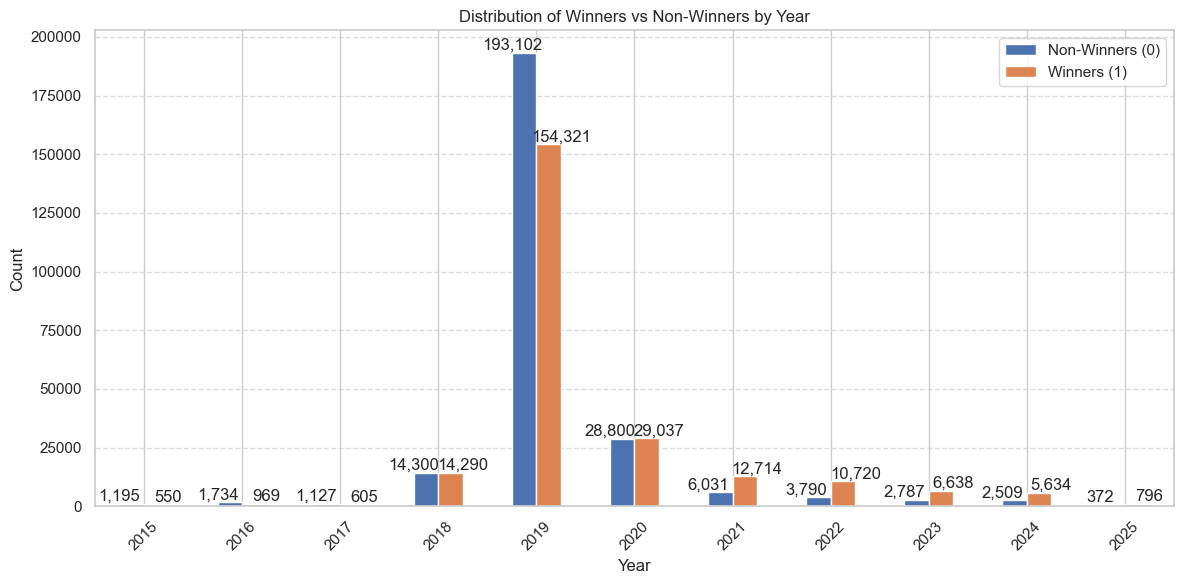

In [181]:
plt.figure(figsize=(12, 6))

winner_counts = data.groupby(['year', 'Победитель']).size().unstack(fill_value=0)

if 0 not in winner_counts.columns:
    winner_counts[0] = 0
if 1 not in winner_counts.columns:
    winner_counts[1] = 0

winner_counts.plot(kind='bar', ax=plt.gca())

plt.title('Distribution of Winners vs Non-Winners by Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.legend(['Non-Winners (0)', 'Winners (1)'])
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

for i, year in enumerate(winner_counts.index):
    for j, col in enumerate(winner_counts.columns):
        value = winner_counts.iloc[i, j]
        plt.text(i + (j-0.5)/len(winner_counts.columns), value + 0.5, 
                 f'{value:,}', 
                ha='center', va='bottom')
plt.show()
